In [4]:
import pandas as pd
import matplotlib.pyplot as plt



df = pd.read_csv("/content/telco_customer_churn_cleaned.csv")

df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,TenureGroup,MonthlyRevenue,RevenuePerTenureMonth
0,7590-VHVEG,Female,No,Yes,No,1,No,No phone service,DSL,No,...,No,Month-to-month,Yes,Electronic check,29.85,29.85,0,0-6 Months,29.85,29.850000
1,5575-GNVDE,Male,No,No,No,34,Yes,No,DSL,Yes,...,No,One year,No,Mailed check,56.95,1889.50,0,25-48 Months,56.95,55.573529
2,3668-QPYBK,Male,No,No,No,2,Yes,No,DSL,Yes,...,No,Month-to-month,Yes,Mailed check,53.85,108.15,1,0-6 Months,53.85,54.075000
3,7795-CFOCW,Male,No,No,No,45,No,No phone service,DSL,Yes,...,No,One year,No,Bank transfer (automatic),42.30,1840.75,0,25-48 Months,42.30,40.905556
4,9237-HQITU,Female,No,No,No,2,Yes,No,Fiber optic,No,...,No,Month-to-month,Yes,Electronic check,70.70,151.65,1,0-6 Months,70.70,75.825000


In [2]:
df.groupby("Contract")["Churn"].mean() * 100

,Churn
Contract,
Month-to-month,42.709677
One year,11.269518
Two year,2.831858


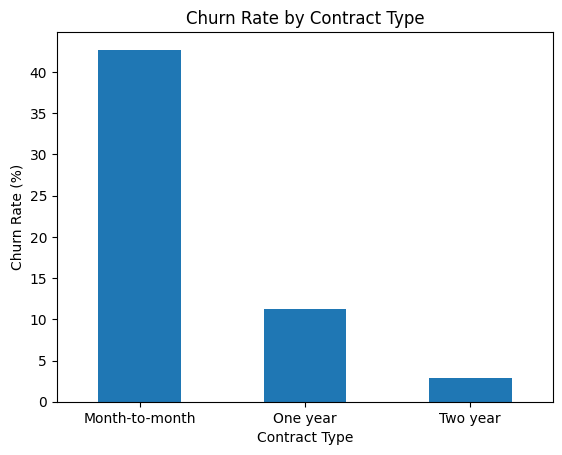

In [5]:
df.groupby("Contract")["Churn"].mean().mul(100).plot(kind="bar")

plt.title("Churn Rate by Contract Type")
plt.xlabel("Contract Type")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=0)
plt.show()

Month-to-month customers exhibit substantially higher churn than customers on longer-term contracts, indicating that contract commitment is a major retention risk factor.

In [6]:
drivers = ["PaymentMethod", "InternetService", "TechSupport", "OnlineSecurity"]

for column in drivers:
    print("\n", column)
    print(df.groupby(column)["Churn"].mean().mul(100).round(2))


 PaymentMethod
PaymentMethod
Bank transfer (automatic)    16.71
Credit card (automatic)      15.24
Electronic check             45.29
Mailed check                 19.11
Name: Churn, dtype: float64

 InternetService
InternetService
DSL            18.96
Fiber optic    41.89
No              7.40
Name: Churn, dtype: float64

 TechSupport
TechSupport
No                     41.64
No internet service     7.40
Yes                    15.17
Name: Churn, dtype: float64

 OnlineSecurity
OnlineSecurity
No                     41.77
No internet service     7.40
Yes                    14.61
Name: Churn, dtype: float64


In [7]:
df.groupby("Churn")["MonthlyCharges"].mean().round(2)

,MonthlyCharges
Churn,
0,61.27
1,74.44
